In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

In [2]:
# Load traffic dataset
df = pd.read_csv("traffic.csv")

# Display first rows
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,21-08-2021,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,21-08-2021,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,21-08-2021,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,21-08-2021,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,21-08-2021,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [26]:
# Check dataset info
df.info()

# Check missing values
df.isnull().sum()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Remove duplicates
df = df.drop_duplicates()

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 122567 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    122567 non-null  object        
 1   date     122567 non-null  datetime64[ns]
 2   country  122562 non-null  object        
 3   city     122562 non-null  object        
 4   artist   122539 non-null  object        
 5   album    122563 non-null  object        
 6   track    122563 non-null  object        
 7   isrc     116261 non-null  object        
 8   linkid   122567 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 9.4+ MB


C:\Users\DELL\AppData\Local\Temp\ipykernel_10228\3287878225.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [27]:
# Total events
total_events = df.shape[0]

# Unique users (based on linkid)
total_users = df['linkid'].nunique()

print("Total Events:", total_events)
print("Total Users:", total_users)

Total Events: 122567
Total Users: 3839


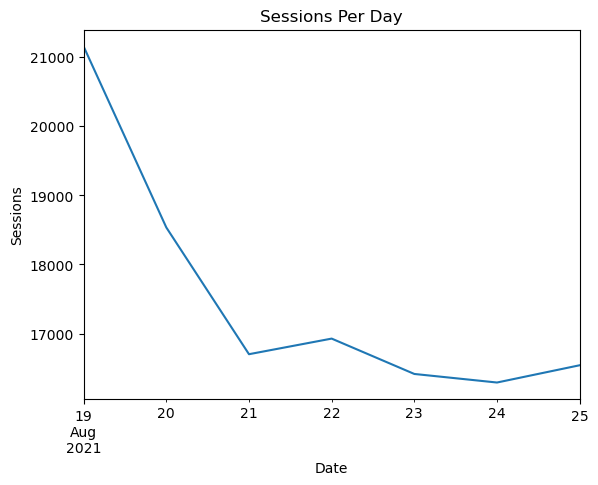

In [28]:
sessions_per_day = df.groupby('date').size()

plt.figure()
sessions_per_day.plot(kind='line')
plt.title("Sessions Per Day")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.show()

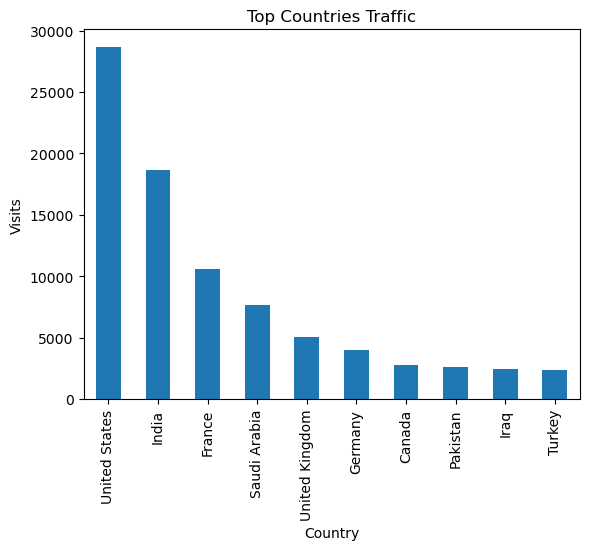

In [29]:
top_countries = df['country'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top Countries Traffic")
plt.xlabel("Country")
plt.ylabel("Visits")
plt.show()

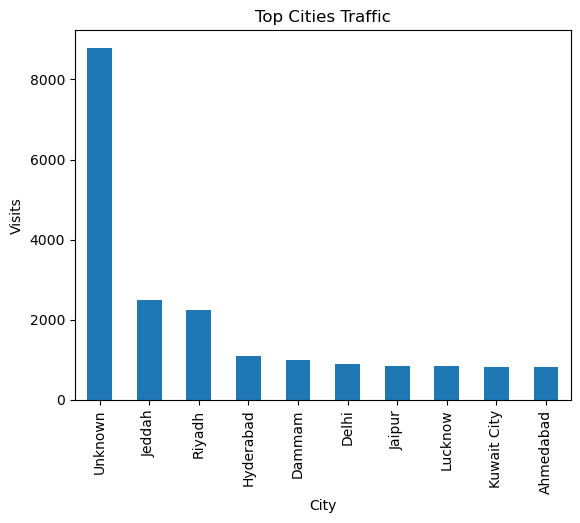

In [30]:
top_cities = df['city'].value_counts().head(10)

plt.figure()
top_cities.plot(kind='bar')
plt.title("Top Cities Traffic")
plt.xlabel("City")
plt.ylabel("Visits")
plt.show()

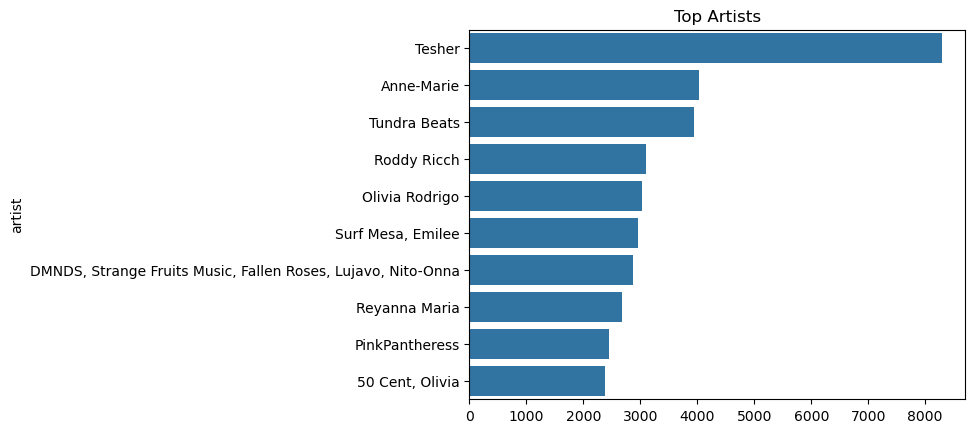

In [31]:
top_artists = df['artist'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Top Artists")
plt.show()

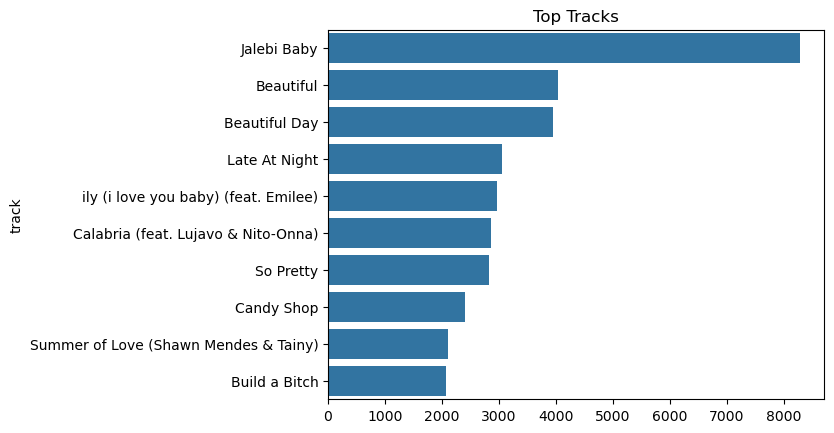

In [32]:
top_tracks = df['track'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_tracks.values, y=top_tracks.index)
plt.title("Top Tracks")
plt.show()

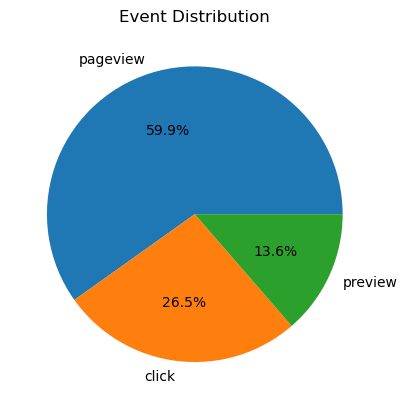

In [33]:
event_counts = df['event'].value_counts()

plt.figure()
event_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Event Distribution")
plt.ylabel("")
plt.show()

In [34]:
user_activity = df.groupby('linkid').size()

bounces = user_activity[user_activity == 1].count()

bounce_rate = (bounces / total_users) * 100

print("Bounce Rate:", bounce_rate)

Bounce Rate: 35.556134410002606


In [35]:
session_time = df.groupby('linkid')['date'].agg(['min','max'])

session_time['duration'] = (session_time['max'] - session_time['min']).dt.seconds

avg_session_duration = session_time['duration'].mean()

print("Average Session Duration:", avg_session_duration)

Average Session Duration: 0.0


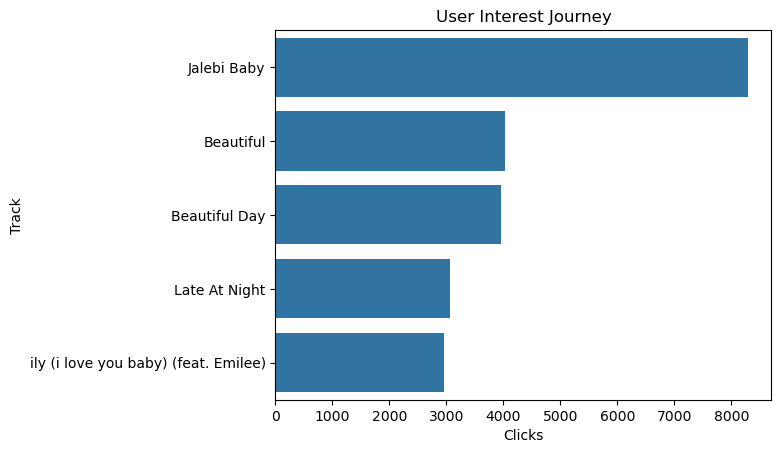

In [36]:
top_tracks = df['track'].value_counts().head(5)

plt.figure()
sns.barplot(x=top_tracks.values, y=top_tracks.index)
plt.title("User Interest Journey")
plt.xlabel("Clicks")
plt.ylabel("Track")
plt.show()